# 🧠 Module 6: Full AI System

---

## 🎯 Objective
Build a complete AI assistant with:

- ✅ RAG (knowledge retrieval)
- ✅ Agents (tool usage)
- ✅ Memory (context awareness)

## 🏗 Architecture
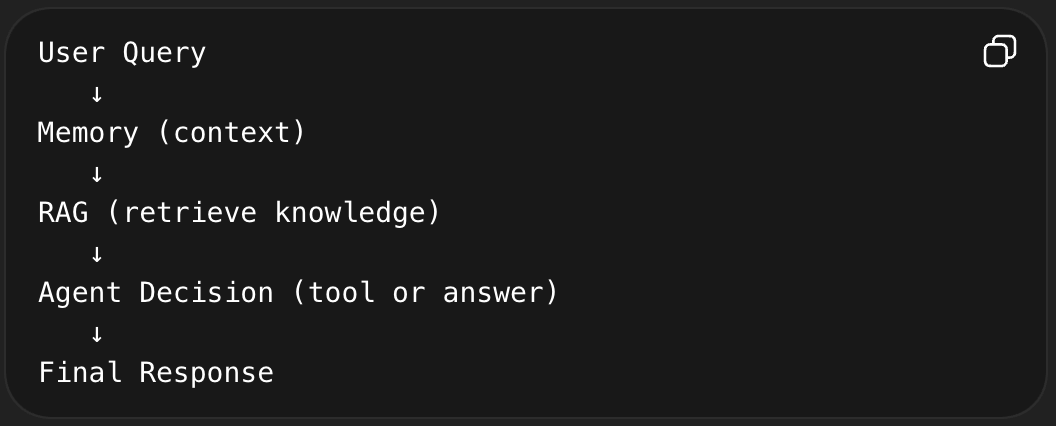

## ⚙️ Setup (Base setup)

In [1]:
import requests
import json
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

# LLM
def ask_llm(prompt, model="mistral"):
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": model,
            "prompt": prompt,
            "stream": False
        }
    )
    return response.json()["response"]

# Embedding model
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

/Users/abhishekjha/Documents/ai-learning/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


#### 🧩 Step 1: Memory (Sliding Window)

In [2]:
chat_history = []
MAX_HISTORY = 3

def add_memory(user, ai):
    chat_history.append({"user": user, "ai": ai})
    if len(chat_history) > MAX_HISTORY:
        chat_history.pop(0)

#### 🧩 Step 2: RAG

In [4]:
documents = [
    "Python is used for AI and backend development",
    "FAISS helps in similarity search",
    "RAG combines retrieval with generation",
    "Agents can use tools to perform actions"
]

doc_embeddings = embedding_model.encode(documents)

index = faiss.IndexFlatL2(doc_embeddings.shape[1])
index.add(doc_embeddings)


def retrieve(query, k=2):
    query_vec = embedding_model.encode([query])
    _, indices = index.search(query_vec, k)
    return [documents[i] for i in indices[0]]

#### 🧩 Step 3: Tools

In [5]:
def calculator(expression):
    try:
        return str(eval(expression))
    except:
        return "Error"

def get_time():
    from datetime import datetime
    return str(datetime.now())

#### 🧩 Step 4: Agent Logic

In [6]:
def decide(query, context):
    prompt = f"""
    You are an AI assistant.

    Context:
    {context}

    Decide:
    - If math → calculator
    - If time → get_time
    - Else → answer

    Return JSON:
    {{
        "action": "...",
        "input": "..."
    }}

    Query:
    {query}
    """
    
    response = ask_llm(prompt)
    
    try:
        return json.loads(response)
    except:
        return {"action": "answer", "input": response}

#### 🧩 Step 5: Final Pipeline

In [7]:
def full_ai(query):
    # Step 1: Memory context
    history_text = ""
    for chat in chat_history:
        history_text += f"User: {chat['user']}\nAI: {chat['ai']}\n"
    
    # Step 2: Retrieve knowledge
    retrieved = retrieve(query)
    context = "\n".join(retrieved)
    
    # Step 3: Agent decision
    decision = decide(query, context + "\n" + history_text)
    
    action = decision.get("action")
    tool_input = decision.get("input")
    
    # Step 4: Execute
    if action == "calculator":
        result = calculator(tool_input)
    elif action == "get_time":
        result = get_time()
    else:
        result = tool_input
    
    # Step 5: Save memory
    add_memory(query, result)
    
    return result

## 🏗 Final Project: AI Assistant

In [9]:
print("\n--- AI Assistant Started ---\n")

while True:
    user_input = input("You:\n> ")
    
    if user_input.lower() in ["exit", "quit"]:
        print("\nGoodbye 👋\n")
        break
    
    response = full_ai(user_input)
    
    print("\nAI:\n", response)
    print("\n" + "-"*50 + "\n")


--- AI Assistant Started ---



You:
>  what is agent



AI:
 An 'agent' in the context provided refers to a software or hardware entity that can interact with its environment and use tools to perform actions. This term is often used in AI, robotics, and software development.

--------------------------------------------------



You:
>  what is python



AI:
 Python is a high-level, interpreted programming language commonly used for AI, web development, and backend services.

--------------------------------------------------



...


AI:
 JavaScript is a high-level, interpreted programming language that is primarily used for building web applications. It is essential for frontend development and can also be used for backend services with certain frameworks.

--------------------------------------------------



You:
>  what is 5+5



AI:
 The result of 5 + 5 is 10.

--------------------------------------------------



You:
>  QUIT



Goodbye 👋

